# Lab: Logistic Regression

**BINF 6210/8210 - Machine Learning for Bioinformatics**
___

## Learning objectives
- Build a binary logistic-regression classifier.
- Distinguish probabilities from hard labels.
- Interpret coefficients and odds ratios cautiously.
- Examine the effect of changing the classification threshold.
- Use a `Pipeline` to avoid preprocessing leakage.

## Outline
1. Understand the data
2. Sigmoid function
3. Build a logistic regression model
4. Effect of the probability threshold on classifier performance
5. Questions
6. Optional: regularization strength

## 1. Understand the data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [2]:
data = load_breast_cancer(as_frame=True)
print(data.DESCR)

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [3]:
# Feature characteristics

X = data.data.copy()

print(f'data shape: {X.shape}')
print(f'\nfeature names:\n {data.feature_names}')

print('\nFeature statistics:')
X.describe().T[["mean","std","min","max"]].head(10)

data shape: (569, 30)

feature names:
 ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

Feature statistics:


,mean,std,min,max
mean radius,14.127292,3.524049,6.98100,28.11000
mean texture,19.289649,4.301036,9.71000,39.28000
mean perimeter,91.969033,24.298981,43.79000,188.50000
mean area,654.889104,351.914129,143.50000,2501.00000
mean smoothness,0.096360,0.014064,0.05263,0.16340
mean compactness,0.104341,0.052813,0.01938,0.34540
mean concavity,0.088799,0.079720,0.00000,0.42680
mean concave points,0.048919,0.038803,0.00000,0.20120
mean symmetry,0.181162,0.027414,0.10600,0.30400
mean fractal dimension,0.062798,0.007060,0.04996,0.09744


In [4]:
# Target statistics

print(f'target names:\n {data.target_names}')
print(f'\ntarget statistics:')
print(pd.Series(data.target).value_counts())

# In the original data, 0 = malignant and 1 = benign

target names:
 ['malignant' 'benign']

target statistics:
target
1    357
0    212
Name: count, dtype: int64


In [5]:
# Recode so malignant = 1 (positive class), benign = 0
y = (data.target == 0).astype(int)
y.name = "malignant"
print(f'y value counts:\n {y.value_counts()}')

y value counts:
 malignant
0    357
1    212
Name: count, dtype: int64


## 2. Sigmoid function

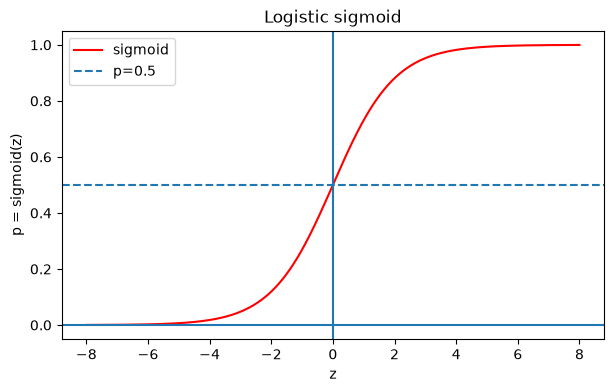

In [6]:
# plot the sigmoid function

z = np.linspace(-8,8,400)
sigmoid = 1/(1+np.exp(-z))
plt.figure(figsize=(7,4))
plt.plot(z, sigmoid, color="red", label="sigmoid")
plt.axhline(0.5, linestyle="--", label='p=0.5')
plt.axhline(0)
plt.axvline(0)
plt.xlabel("z")
plt.ylabel("p = sigmoid(z)")
plt.title("Logistic sigmoid")
plt.legend()
plt.show()

## 3. Build a logistic regression model

In [7]:
# split the data for training
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=6210
)

### Fit a leakage-safe pipeline

In [17]:
# StandardScaler is applied to the training data only
lr_model = Pipeline([
    ("scale", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000, random_state=6210))
])
lr_model.fit(X_train, y_train)

# retrieve the mean and standard deviation of features after the pipeline has been applied to the training data

scaler_stats = pd.DataFrame({
    "Feature": X_train.columns,
    "Mean": lr_model.named_steps["scale"].mean_,
    "Std": lr_model.named_steps["scale"].scale_
})
print(scaler_stats)

                    Feature        Mean         Std
0               mean radius   14.119056    3.538028
1              mean texture   19.265211    4.257196
2            mean perimeter   91.875493   24.320358
3                 mean area  654.507512  346.455564
4           mean smoothness    0.095981    0.013793
5          mean compactness    0.103427    0.051877
6            mean concavity    0.089011    0.078752
7       mean concave points    0.048650    0.038019
8             mean symmetry    0.180494    0.027746
9    mean fractal dimension    0.062745    0.006986
10             radius error    0.406989    0.267915
11            texture error    1.225356    0.567030
12          perimeter error    2.876247    1.952243
13               area error   40.315685   42.186062
14         smoothness error    0.007060    0.003072
15        compactness error    0.025797    0.018465
16          concavity error    0.033020    0.032401
17     concave points error    0.011882    0.006266
18          

The mean and standard deviation computed from the training data will be used to standardize the testing data. So using a `Pipeline` prevents accidentally introducing data leakage.

Note: `StandardScaler.scale_` uses the population standard deviation convention (`ddof=0`), so it may differ slightly from pandas.DataFrame.std(), whose default `ddof=1`.

In [15]:
# Obtain the training and testing accuracy
print("Training accuracy:", lr_model.score(X_train, y_train))
print("Test accuracy:", lr_model.score(X_test, y_test))

Training accuracy: 0.9812206572769953
Test accuracy: 1.0


### Probabilities versus labels

In [21]:
# Obtain the probability p(Y=1|x; theta) for each testing sample
y_prob = lr_model.predict_proba(X_test)[:,1]

# Obtain the predicted labels for each testing sample
y_pred = lr_model.predict(X_test)

preview = pd.DataFrame({
    "actual tumor label": y_test.to_numpy()[:12],
    "P(malignant)": y_prob[:12],
    "predicted tumor label": y_pred[:12]
})
preview

,actual tumor label,P(malignant),predicted tumor label
0,0,0.000213,0
1,0,0.000642,0
2,0,0.398209,0
3,0,0.000260,0
4,1,0.999993,1
5,0,0.031115,0
6,1,0.999128,1
7,0,0.002968,0
8,0,0.160029,0
9,0,0.006532,0


### Standardized coefficients and odds ratios
Because predictors are standardized via `StandardScaler`, each coefficient corresponds to approximately a one-standard-deviation increase in that predictor. Correlation among features means coefficients should not be read as independent biomarker importance.

In [22]:
coef = pd.Series(lr_model.named_steps["clf"].coef_[0], index=X.columns)
coef_table = pd.DataFrame({
    "coefficient": coef,
    "odds_ratio_per_1_SD": np.exp(coef)
}).sort_values("coefficient")
print(coef_table)
# pd.concat([coef_table.head(5), coef_table.tail(5)])

                         coefficient  odds_ratio_per_1_SD
fractal dimension error    -0.765520             0.465092
compactness error          -0.600611             0.548477
mean compactness           -0.544959             0.579866
symmetry error             -0.421971             0.655753
concavity error            -0.144273             0.865652
texture error              -0.061739             0.940128
mean fractal dimension     -0.005923             0.994094
mean symmetry              -0.000118             0.999882
worst compactness           0.059574             1.061384
mean texture                0.236577             1.266905
concave points error        0.238631             1.269510
mean smoothness             0.244387             1.276838
mean perimeter              0.270960             1.311222
worst fractal dimension     0.300499             1.350533
smoothness error            0.302732             1.353551
mean radius                 0.308535             1.361429
worst smoothne

## 5. Effect of the probability threshold on classifier performance

In [23]:
for threshold in [0.2, 0.5, 0.8]:
    pred_t = (y_prob >= threshold).astype(int)
    print(threshold, "predicted malignant:", pred_t.sum(), "accuracy:", (pred_t==y_test.to_numpy()).mean())

0.2 predicted malignant: 59 accuracy: 0.958041958041958
0.5 predicted malignant: 53 accuracy: 1.0
0.8 predicted malignant: 49 accuracy: 0.972027972027972


## 6. Questions
1. Why does lowering the threshold usually increase sensitivity?
2. Why is `predict_proba()` more informative than `predict()` for threshold analysis?
3. Does a large standardized coefficient establish causality? Why not?

## 7. Optional: regularization strength

In [ ]:
for C in [0.01, 0.1, 1, 10, 100]:
    m = Pipeline([("scale", StandardScaler()),
                  ("clf", LogisticRegression(C=C, max_iter=5000, random_state=6210))])
    m.fit(X_train,y_train)
    norm = np.linalg.norm(m.named_steps["clf"].coef_)
    print(f"C={C:6g}  train={m.score(X_train,y_train):.3f} test={m.score(X_test,y_test):.3f} ||beta||={norm:.3f}")

## 8. Take-home message
Logistic regression produces class probabilities through a sigmoid transformation of a linear predictor. Hard classification requires a threshold, and regularization/preprocessing choices are part of the model.